In [1]:
# 1ブロック目: ライブラリのインストールとimport確認
# 方針:
# - Kaggle Notebookで事前import済みになりやすい numpy / scipy / scikit-learn / Pillow は入れ替えません。
# - C拡張系ライブラリを同一kernel内でuninstall/reinstallすると、NumPy/SciPy/Pillowの混在エラーが起きます。
# - road_detection_AI()で直接使う YOLO26 / PaddleOCR / Gemma4 用ライブラリだけを追加します。
# - P100(sm_60)の場合だけ、torch import前に torch 2.7.1+cu118 / torchvision 0.22.1+cu118 へ切り替えます。
# - T4/A100など compute capability >= 7 のGPUでは、Kaggle標準torchを維持します。
# - Gemma4はT4のVRAM節約のため bitsandbytes 4-bit 量子化でロードします。

import importlib.metadata as im
import os
import subprocess
import sys
from pathlib import Path

os.environ["DISABLE_MODEL_SOURCE_CHECK"] = "True"
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")


def installed_version(package_name):
    try:
        return im.version(package_name)
    except im.PackageNotFoundError:
        return None


def run(cmd, check=True):
    print("+", " ".join(cmd), flush=True)
    return subprocess.run(cmd, check=check)


def parse_version_tuple(version):
    if version is None:
        return None
    base = version.split("+")[0].split("-")[0]
    parts = []
    for part in base.split(".")[:3]:
        digits = "".join(ch for ch in part if ch.isdigit())
        parts.append(int(digits or 0))
    while len(parts) < 3:
        parts.append(0)
    return tuple(parts)


def version_in_range(version, lower, upper):
    parsed = parse_version_tuple(version)
    return parsed is not None and parse_version_tuple(lower) <= parsed < parse_version_tuple(upper)


preloaded = [name for name in ["numpy", "PIL", "scipy", "sklearn", "torch"] if name in sys.modules]
print("preloaded modules kept as-is:", preloaded)

# uvはインストール用にだけ使います。ここでは既存C拡張系ライブラリを入れ替えません。
run([sys.executable, "-m", "pip", "install", "-q", "uv"])

# torchをimportする前にnvidia-smiでGPUを判定します。
# P100ではKaggle標準torchがsm_60非対応になるため、torch未importの場合だけcu118版へ切り替えます。
try:
    gpu_name = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True
    ).strip()
    compute_cap = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=compute_cap", "--format=csv,noheader"], text=True
    ).strip()
    print("GPU:", gpu_name)
    print("GPU compute capability:", compute_cap)
    first_capability = int(compute_cap.splitlines()[0].split(".")[0])
    if first_capability < 7:
        if "torch" in sys.modules:
            raise RuntimeError(
                "P100 requires torch==2.7.1+cu118, but torch is already imported. "
                "Restart Session and run this first block before importing torch."
            )
        run([
            sys.executable, "-m", "uv", "pip", "install", "--system", "-q",
            "--index-url", "https://download.pytorch.org/whl/cu118",
            "torch==2.7.1", "torchvision==0.22.1",
        ])
except Exception as e:
    print(f"GPU probe warning: {type(e).__name__}: {e}")

# Gemma4は transformers 5.x のAutoModelForMultimodalLMでのロード成功例に合わせます。
# すでにtransformers/accelerateをimport済みのkernelではupgradeしても反映されないため、Session Restart後にこのセルを先頭実行してください。
if "transformers" in sys.modules or "accelerate" in sys.modules:
    raise RuntimeError(
        "transformers/accelerate is already imported before Gemma4-compatible upgrade. "
        "Restart Session and run this first block before importing transformers."
    )

run([
    sys.executable, "-m", "pip", "install", "-q", "--upgrade",
    "transformers>=5.0.0,<6",
    "accelerate>=1.12.0,<2",
])

# モデル実行に必要なライブラリだけを入れます。
# numpy/scipy/sklearn/pillow はここで指定せず、Kaggle標準または現在kernel上のものを維持します。
packages = [
    "ultralytics>=8.3.0,<9",
    "transformers>=5.0.0,<6",
    "accelerate>=1.12.0,<2",
    "sentencepiece>=0.2.0",
    "bitsandbytes>=0.49.0",
    "paddlepaddle>=3.0.0,<4",
    "paddleocr>=3.3.0,<4",
    "paddlex[ocr]>=3.3.0,<4",
    "langchain==0.3.30",
    "langchain-community==0.3.31",
    "pymongo>=4.6.0",
]

run([sys.executable, "-m", "uv", "pip", "install", "--system", "-q", *packages])

print("after install metadata:")
for package_name in [
    "numpy", "scipy", "scikit-learn", "pandas", "pillow", "torch", "torchvision",
    "ultralytics", "transformers", "accelerate", "bitsandbytes", "paddlepaddle", "paddleocr", "paddlex",
    "langchain", "langchain-community", "pymongo",
]:
    print(f"{package_name}: {installed_version(package_name)}")

# import確認。C拡張系は入れ替えず、実際に使うライブラリを中心に確認します。
import numpy as np
print("numpy ok", np.__version__, "UInt32DType:", hasattr(getattr(np, "dtypes", None), "UInt32DType"))

import PIL
from PIL import Image, ImageDraw
print("pillow ok", installed_version("pillow"))

import torch
import torchvision
print("torch ok", torch.__version__)
print("torchvision ok", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

from ultralytics import YOLO
print("ultralytics ok", installed_version("ultralytics"))

import transformers
from transformers import (
    AutoModelForCausalLM,
    AutoModelForImageTextToText,
    AutoModelForMultimodalLM,
    AutoProcessor,
    BitsAndBytesConfig,
    GenerationConfig,
)
try:
    import transformers.models.gemma4
except Exception as e:
    raise RuntimeError(
        "Transformers does not expose Gemma4 support. "
        "Restart Session, run this first block first, and confirm transformers>=5.0.0 is installed."
    ) from e
print("transformers ok", transformers.__version__, "gemma4 support: yes")

import accelerate
print("accelerate ok", accelerate.__version__)

import bitsandbytes as bnb
from transformers import BitsAndBytesConfig
print("bitsandbytes ok", installed_version("bitsandbytes"))

import sentencepiece
print("sentencepiece ok", installed_version("sentencepiece"))

import paddle
print("paddle ok", paddle.__version__)

import langchain
import langchain_community
print("langchain ok", installed_version("langchain"), installed_version("langchain-community"))

import pymongo
print("pymongo ok", pymongo.version)

import paddleocr
import paddlex
from paddleocr import PaddleOCR
print("paddleocr ok", installed_version("paddleocr"))
print("paddlex ok", installed_version("paddlex"))

bnb_config_check = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
print("bitsandbytes 4-bit config ok", bnb_config_check)

print("Python model dependencies installed and import check passed.")


preloaded modules kept as-is: ['numpy', 'PIL']
+ /usr/bin/python3 -m pip install -q uv
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 75.2 MB/s eta 0:00:00
GPU: Tesla T4
Tesla T4
GPU compute capability: 7.5
7.5
+ /usr/bin/python3 -m pip install -q --upgrade transformers>=5.0.0,<6 accelerate>=1.12.0,<2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 110.2 MB/s eta 0:00:00
+ /usr/bin/python3 -m uv pip install --system -q ultralytics>=8.3.0,<9 transformers>=5.0.0,<6 accelerate>=1.12.0,<2 sentencepiece>=0.2.0 bitsandbytes>=0.49.0 paddlepaddle>=3.0.0,<4 paddleocr>=3.3.0,<4 paddlex[ocr]>=3.3.0,<4 langchain==0.3.30 langchain-community==0.3.31 pymongo>=4.6.0
after install metadata:
numpy: 2.0.2
scipy: 1.16.3
scikit-learn: 1.6.1
pandas: 2.3.

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


paddle ok 3.3.1
langchain ok 0.3.30 0.3.31
pymongo ok 4.16.0
paddleocr ok 3.5.0
paddlex ok 3.5.2
bitsandbytes 4-bit config ok BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}

Python model dependencies installed and import check passed.


In [2]:
# 2ブロック目: GPU, VRAM(RAM)に関する情報
import os
import gc
import json
import time
import random
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from IPython.display import display, JSON, Markdown

import psutil
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DEVICE: {DEVICE}")
print(f"CPU count: {psutil.cpu_count(logical=True)}")
print(f"RAM total: {psutil.virtual_memory().total / 1024**3:.2f} GB")
print(f"RAM available: {psutil.virtual_memory().available / 1024**3:.2f} GB")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}: {props.name}")
        print(f"  VRAM total: {props.total_memory / 1024**3:.2f} GB")
        print(f"  capability: {props.major}.{props.minor}")
    try:
        print("\n--- nvidia-smi ---")
        print(subprocess.check_output(["nvidia-smi"], text=True))
    except Exception as e:
        print(f"nvidia-smi unavailable: {e}")
else:
    print("GPU is not available. Kaggle Notebook accelerator should be set to GPU for Gemma4.")


DEVICE: cuda
CPU count: 4
RAM total: 31.35 GB
RAM available: 29.25 GB
GPU 0: Tesla T4
  VRAM total: 14.56 GB
  capability: 7.5
GPU 1: Tesla T4
  VRAM total: 14.56 GB
  capability: 7.5

--- nvidia-smi ---
Fri May 15 09:01:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8           

In [3]:
# 3ブロック目: データセットの準備
DATASET_DIR = Path("/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset path not found: {DATASET_DIR}\n"
        "Kaggle Notebook の Add input で japanese-traffic-signs-dataset が追加されているか確認してください。"
    )

all_image_paths = sorted([p for p in DATASET_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS])
if len(all_image_paths) == 0:
    raise RuntimeError(f"No image files found under {DATASET_DIR}")

print(f"Dataset directory: {DATASET_DIR}")
print(f"Number of images: {len(all_image_paths)}")
print("First 5 image paths:")
for p in all_image_paths[:5]:
    print(" -", p)


Dataset directory: /kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train
Number of images: 852
First 5 image paths:
 - /kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/1000793147445847.jpg
 - /kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/1001606751987479.jpg
 - /kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/1022534698590816.jpg
 - /kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/1029215347929881.jpg
 - /kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/1031830024291028.jpg


Sampled 10 images. Variable name: images
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/143479704409743.jpg
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/1099018513924069.jpg
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/750712403925723.jpg
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/229864755576074.jpg
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/207599881550070.jpg
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/1934583786703977.jpg
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/149775753779958.jpg
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/train/732178404146229.jpg
/kaggle/input/datasets/sophalratitya/japanese-traffic-signs-dataset/dataset/images/tr

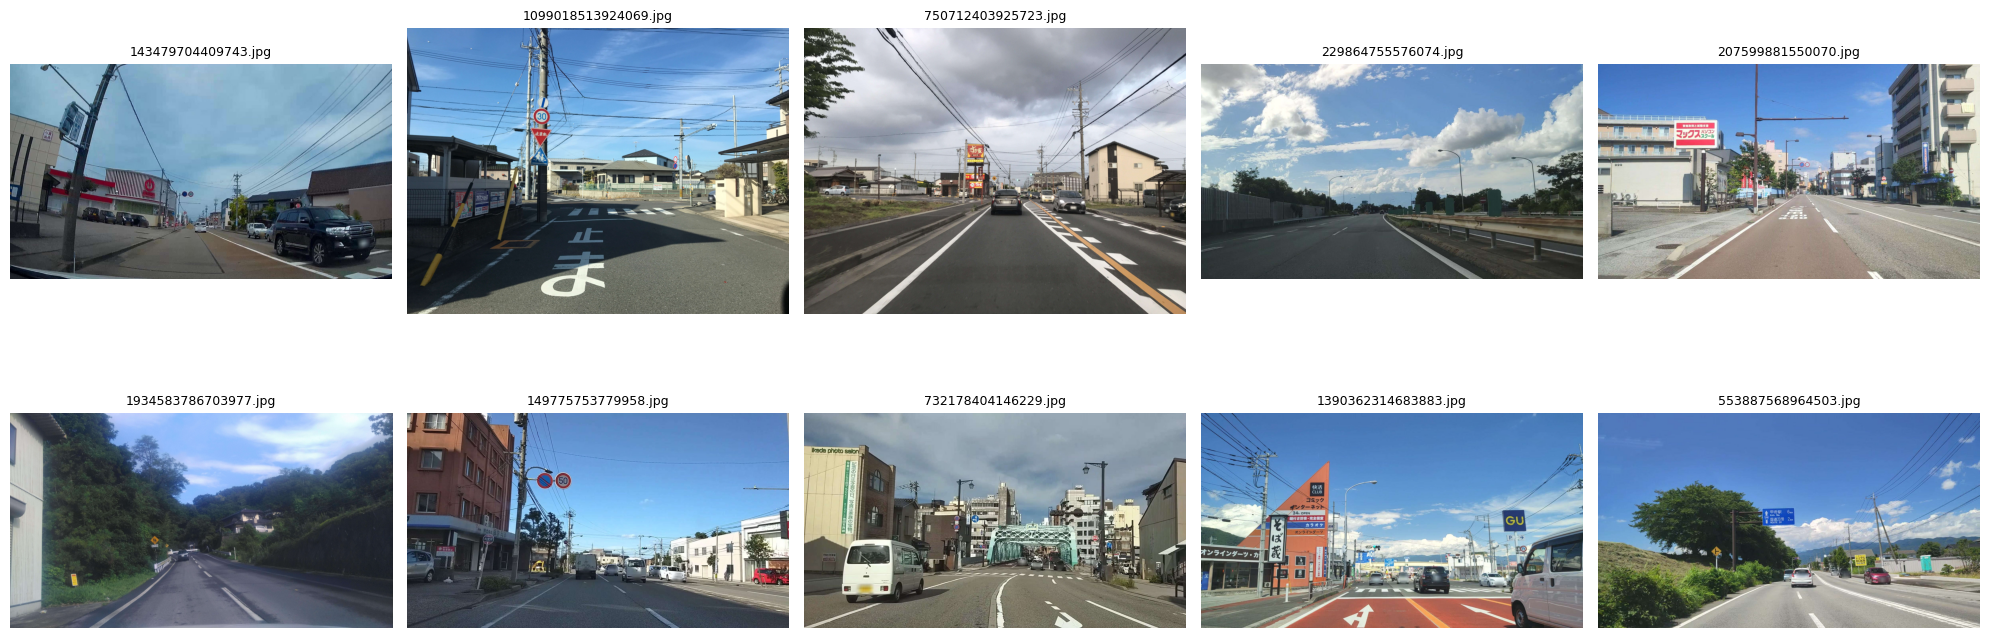

In [4]:
# 4ブロック目: データセットをランダムに5~10枚ほど抽出して、表示する
sample_count = random.randint(5, 10)
images = random.sample(all_image_paths, k=min(sample_count, len(all_image_paths)))

print(f"Sampled {len(images)} images. Variable name: images")
for p in images:
    print(p)

cols = min(5, len(images))
rows = int(np.ceil(len(images) / cols))
plt.figure(figsize=(4 * cols, 4 * rows))
for idx, image_path in enumerate(images, 1):
    img = Image.open(image_path).convert("RGB")
    plt.subplot(rows, cols, idx)
    plt.imshow(img)
    plt.title(image_path.name, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [5]:
# 5ブロック目: モデルダウンロード
# Kaggle MCP で確認した既存 notebook のモデル取得コードを反映しています。
# YOLO26_test: ultralytics の YOLO("yolo26n.pt") が重みを自動取得します。
# Paddle_OCR_test: paddleocr が公式 OCR モデルを初回実行時に自動取得します。
# gemma4_test_text_image: Kaggle Model path /kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1 を使用します。

from ultralytics import YOLO
from paddleocr import PaddleOCR
import transformers
from transformers import (
    AutoModelForCausalLM,
    AutoModelForImageTextToText,
    AutoModelForMultimodalLM,
    AutoProcessor,
    BitsAndBytesConfig,
    GenerationConfig,
)

YOLO_MODEL_NAME = "yolo26n.pt"
GEMMA4_MODEL_PATH = Path("/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1")

print("Loading YOLO26...")
yolo_model = YOLO(YOLO_MODEL_NAME)
print("YOLO26 loaded:", YOLO_MODEL_NAME)

print("Loading PaddleOCR...")
ocr_init_errors = []
ocr = None
for kwargs in (
    {"use_angle_cls": True, "lang": "japan", "show_log": False},
    {"use_angle_cls": True, "lang": "japan"},
    {"use_textline_orientation": True, "lang": "japan"},
    {"lang": "japan"},
):
    try:
        ocr = PaddleOCR(**kwargs)
        print("PaddleOCR loaded with kwargs:", kwargs)
        break
    except Exception as e:
        ocr_init_errors.append(f"{kwargs}: {repr(e)}")
if ocr is None:
    raise RuntimeError("PaddleOCR load failed:\n" + "\n".join(ocr_init_errors))

if not GEMMA4_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Gemma4 model path not found: {GEMMA4_MODEL_PATH}\n"
        "Kaggle Notebook の Add input で google/gemma-4/Transformers/gemma-4-e4b-it/1 を追加してください。"
    )

print("Loading Gemma4 processor/model...")
try:
    import transformers.models.gemma4
except Exception as e:
    raise RuntimeError(
        f"Gemma4 requires a transformers build with gemma4 support; current version is {transformers.__version__}. "
        "Restart Session and run the first block before this cell."
    ) from e
print("transformers ok", transformers.__version__, "gemma4 support: yes")

processor = AutoProcessor.from_pretrained(str(GEMMA4_MODEL_PATH), trust_remote_code=True)

gemma4_quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
print("Gemma4 quantization: bitsandbytes 4-bit NF4")

model_load_errors = []
model = None
for model_cls in (AutoModelForMultimodalLM, AutoModelForImageTextToText, AutoModelForCausalLM):
    try:
        model = model_cls.from_pretrained(
            str(GEMMA4_MODEL_PATH),
            dtype="auto",
            device_map="auto" if torch.cuda.is_available() else None,
            low_cpu_mem_usage=True,
            quantization_config=gemma4_quantization_config if torch.cuda.is_available() else None,
            trust_remote_code=True,
        )
        print(f"Gemma4 loaded with {model_cls.__name__}")
        break
    except Exception as e:
        model_load_errors.append(f"{model_cls.__name__}: {repr(e)}")

if model is None:
    raise RuntimeError("Gemma4 model load failed:\n" + "\n".join(model_load_errors))

model.eval()
try:
    print("Gemma4 memory footprint GB:", round(model.get_memory_footprint() / 1024**3, 3))
except Exception as e:
    print(f"Gemma4 memory footprint unavailable: {type(e).__name__}: {e}")
print("Gemma4 model path:", GEMMA4_MODEL_PATH)


Loading YOLO26...


/tmp/ipykernel_57/2569711049.py:36: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(**kwargs)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


YOLO26 loaded: yolo26n.pt
Loading PaddleOCR...


Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
[2026-05-15 09:02:09,780] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/PaddlePaddle/PP-LCNet_x1_0_doc_ori/revision/main "HTTP/1.1 200 OK"


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

...

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

[2026-05-15 09:02:15,683] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-OCRv5_server_rec/resolve/b26c3587fda8da3c8ec0ce357214b4d661ff1558/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-05-15 09:02:15,690] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-OCRv5_server_rec/resolve/b26c3587fda8da3c8ec0ce357214b4d661ff1558/inference.yml "HTTP/1.1 307 Temporary Redirect"
[2026-05-15 09:02:15,698] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/PaddlePaddle/PP-OCRv5_server_rec/b26c3587fda8da3c8ec0ce357214b4d661ff1558/config.json "HTTP/1.1 200 OK"
[2026-05-15 09:02:15,707] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/PaddlePaddle/PP-OCRv5_server_rec/b26c3587fda8da3c8ec0ce357214b4d661ff1558/inference.yml "HTTP/1.1 200 OK"
[2026-05-15 09:02:15,715] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.c

PaddleOCR loaded with kwargs: {'use_angle_cls': True, 'lang': 'japan'}
Loading Gemma4 processor/model...
transformers ok 5.8.1 gemma4 support: yes
Gemma4 quantization: bitsandbytes 4-bit NF4


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Gemma4 loaded with AutoModelForMultimodalLM
Gemma4 memory footprint GB: 8.596
Gemma4 model path: /kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1


In [6]:
# 6ブロック目: AIの一連のフローを組み込んだ関数 road_detection_AI()
# 出力する主要変数:
# - variable1_object_labels: YOLO26 が検出したラベル
# - variable2_ocr_texts: PaddleOCR が抽出した文字/文章
# - mongodb_documents: MongoDB/NoSQL 形式の JSON document
# - gemma4_outputs: Gemma4 の分析結果と性能指標

TEXT_OBJECT_KEYWORDS = {
    "sign", "traffic sign", "stop sign", "signpost", "billboard", "license plate",
    "traffic light", "board", "poster", "banner"
}

ROAD_RELATED_KEYWORDS = {
    "person", "bicycle", "car", "motorcycle", "bus", "truck", "traffic light", "stop sign",
    "parking meter", "bench", "road", "lane", "white line", "sign", "signpost"
}

def now_time():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

def get_peak_vram_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / 1024**3

def reset_peak_vram():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def release_yolo_cuda_cache():
    if not torch.cuda.is_available():
        return
    try:
        if hasattr(yolo_model, "model") and yolo_model.model is not None:
            yolo_model.model.to("cpu")
    except Exception as e:
        print(f"YOLO CUDA release warning: {type(e).__name__}: {e}")
    gc.collect()
    torch.cuda.empty_cache()

def pil_open_rgb(path):
    return Image.open(path).convert("RGB")

def run_yolo(image_paths, conf=0.25, imgsz=640):
    start = now_time()
    results = yolo_model.predict(
        source=[str(p) for p in image_paths],
        conf=conf,
        imgsz=imgsz,
        verbose=False,
        device=0 if torch.cuda.is_available() else "cpu",
    )
    end = now_time()

    detections_by_image = []
    object_labels = []
    for image_path, result in zip(image_paths, results):
        names = result.names
        boxes = []
        if result.boxes is not None:
            for box in result.boxes:
                cls_id = int(box.cls.item())
                label = names.get(cls_id, str(cls_id))
                conf_value = float(box.conf.item())
                xyxy = [float(v) for v in box.xyxy[0].detach().cpu().tolist()]
                boxes.append({
                    "label": label,
                    "confidence": conf_value,
                    "bbox_xyxy": xyxy,
                })
                object_labels.append(label)
        detections_by_image.append({
            "image_path": str(image_path),
            "detections": boxes,
            "number_of_object": len(boxes),
        })
    return detections_by_image, object_labels, end - start

def crop_detection(image_path, bbox_xyxy, pad_ratio=0.05):
    img = pil_open_rgb(image_path)
    w, h = img.size
    x1, y1, x2, y2 = bbox_xyxy
    pad_x = (x2 - x1) * pad_ratio
    pad_y = (y2 - y1) * pad_ratio
    x1 = max(0, int(x1 - pad_x))
    y1 = max(0, int(y1 - pad_y))
    x2 = min(w, int(x2 + pad_x))
    y2 = min(h, int(y2 + pad_y))
    if x2 <= x1 or y2 <= y1:
        return img
    return img.crop((x1, y1, x2, y2))

def parse_paddleocr_result(result):
    texts = []
    if not result:
        return texts
    for line in result:
        if line is None:
            continue
        # PaddleOCR v2 style: [[box], (text, score)]
        if isinstance(line, list):
            for item in line:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    candidate = item[1]
                    if isinstance(candidate, (list, tuple)) and len(candidate) >= 1:
                        text = str(candidate[0]).strip()
                        score = float(candidate[1]) if len(candidate) > 1 else None
                        if text:
                            texts.append({"text": text, "score": score})
        # PaddleOCR newer dict style fallback
        if isinstance(line, dict):
            for key in ("rec_texts", "texts"):
                if key in line and isinstance(line[key], list):
                    for text in line[key]:
                        text = str(text).strip()
                        if text:
                            texts.append({"text": text, "score": None})
    return texts

def run_ocr_for_text_objects(detections_by_image):
    start = now_time()
    ocr_results = []
    text_object_image_paths = []

    for item in detections_by_image:
        image_path = item["image_path"]
        detections = item["detections"]
        sign_like_dets = [
            d for d in detections
            if any(k in d["label"].lower() for k in TEXT_OBJECT_KEYWORDS)
        ]

        image_texts = []
        if sign_like_dets:
            text_object_image_paths.append(image_path)
            for det_idx, det in enumerate(sign_like_dets):
                crop = crop_detection(image_path, det["bbox_xyxy"])
                tmp_path = Path("/kaggle/working") / f"ocr_crop_{Path(image_path).stem}_{det_idx}.png"
                crop.save(tmp_path)
                raw = ocr.ocr(str(tmp_path), cls=True)
                parsed = parse_paddleocr_result(raw)
                for row in parsed:
                    row.update({"source": "detected_object_crop", "object_label": det["label"]})
                image_texts.extend(parsed)

            # 案内標識の文字が crop で欠ける場合に備え、同じ画像全体も OCR する
            raw_full = ocr.ocr(image_path, cls=True)
            parsed_full = parse_paddleocr_result(raw_full)
            for row in parsed_full:
                row.update({"source": "full_image", "object_label": "image_with_text_object"})
            image_texts.extend(parsed_full)

        ocr_results.append({
            "image_path": image_path,
            "has_text_object_by_yolo": bool(sign_like_dets),
            "texts": image_texts,
        })

    end = now_time()
    variable2_ocr_texts = [t["text"] for item in ocr_results for t in item["texts"]]
    text_image_paths = sorted(set([item["image_path"] for item in ocr_results if item["texts"]]))
    if not text_image_paths:
        text_image_paths = sorted(set(text_object_image_paths))
    return ocr_results, variable2_ocr_texts, text_image_paths, end - start

def build_mongodb_documents(detections_by_image, ocr_results):
    ocr_map = {item["image_path"]: item for item in ocr_results}
    documents = []
    for det_item in detections_by_image:
        image_path = det_item["image_path"]
        labels = [d["label"] for d in det_item["detections"]]
        texts = [t["text"] for t in ocr_map.get(image_path, {}).get("texts", [])]
        doc = {
            "image_path": image_path,
            "number_of_object": det_item["number_of_object"],
            "object_label": labels,
            "letter_or_sentence": texts,
            "detections": det_item["detections"],
            "created_for": "gemma4_input",
        }
        documents.append(doc)

    # MongoDB が利用可能な場合のみ保存。未設定なら NoSQL document としてメモリ上で使う。
    mongodb_uri = os.environ.get("MONGODB_URI")
    if mongodb_uri:
        try:
            from pymongo import MongoClient
            client = MongoClient(mongodb_uri, serverSelectionTimeoutMS=5000)
            client.admin.command("ping")
            collection = client["road_detection_ai"]["inference_documents"]
            collection.insert_many(documents)
            print(f"Inserted {len(documents)} documents into MongoDB.")
        except Exception as e:
            print(f"MongoDB insert skipped because connection failed: {e}")
    return documents

def build_prompt(mongodb_documents, has_text_images):
    base_prompt = (
        "あなたは道路状況を分析するAIです。入力JSONと画像から分かることを日本語でまとめてください。"
        "特に、交通状況(混雑しているか)、安全状況(安全ではない場所に人間はいないか、"
        "障害物が道路上にないか)、標識や道路設備から分かる注意点を簡潔に述べてください。"
    )
    if has_text_images:
        base_prompt += (
            " さらに、検出・抽出した文字や文章から、現在の位置、地域、道路環境として"
            "推定できることがあれば、根拠と不確実性を明示して述べてください。"
        )
    json_text = json.dumps(mongodb_documents, ensure_ascii=False, indent=2)
    return base_prompt + "\n\n入力JSON:\n" + json_text

def prepare_gemma_inputs(prompt, image_paths):
    pil_images = [pil_open_rgb(p) for p in image_paths]
    content = []
    for img in pil_images:
        content.append({"type": "image", "image": img})
    content.append({"type": "text", "text": prompt})
    messages = [{"role": "user", "content": content}]

    chat_text = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )
    inputs = processor(
        text=chat_text,
        images=pil_images,
        return_tensors="pt",
    )
    target_device = next(model.parameters()).device
    inputs = {k: (v.to(target_device) if hasattr(v, "to") else v) for k, v in inputs.items()}
    return inputs

def run_gemma4(prompt, image_paths, max_new_tokens=512):
    reset_peak_vram()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    inputs = prepare_gemma_inputs(prompt, image_paths)
    input_token_count = int(inputs["input_ids"].shape[-1]) if "input_ids" in inputs else 0

    generation_config = GenerationConfig(
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=1.0,
    )

    ttft = None
    generated_token_count = 0
    start = now_time()

    with torch.inference_mode():
        output_ids = model.generate(**inputs, generation_config=generation_config)

    end = now_time()
    total_latency = end - start

    if "input_ids" in inputs:
        generated_ids = output_ids[:, inputs["input_ids"].shape[-1]:]
    else:
        generated_ids = output_ids
    generated_token_count = int(generated_ids.shape[-1])

    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    # 通常の generate はストリーミングしないため厳密な TTFT は測れない。推論全体の初回出力近似として記録する。
    ttft = total_latency if generated_token_count > 0 else None
    tps = generated_token_count / total_latency if total_latency > 0 else 0.0
    peak_vram = get_peak_vram_gb()

    return {
        "answer": generated_text,
        "total_latency_sec_1": total_latency,
        "TTFT_sec": ttft,
        "TPS": tps,
        "Peak_VRAM_Usage_GB": peak_vram,
        "generated_token": generated_token_count,
        "input_token": input_token_count,
        "image_paths": [str(p) for p in image_paths],
    }

def road_detection_AI(images, max_random_gemma_images=3, yolo_conf=0.25, yolo_imgsz=640, max_new_tokens=512):
    """
    YOLO26 -> PaddleOCR -> MongoDB-style JSON -> Gemma4 の一連の推論を実行します。
    images: Path または str のリスト。4ブロック目で作成した images 変数を渡してください。
    """
    image_paths = [Path(p) for p in images]

    detections_by_image, variable1_object_labels, yolo_time_2 = run_yolo(
        image_paths, conf=yolo_conf, imgsz=yolo_imgsz
    )
    ocr_results, variable2_ocr_texts, text_image_paths, paddleocr_time_3 = run_ocr_for_text_objects(detections_by_image)
    mongodb_documents = build_mongodb_documents(detections_by_image, ocr_results)

    release_yolo_cuda_cache()

    if text_image_paths:
        gemma_image_paths = [Path(p) for p in text_image_paths]
        has_text_images = True
    else:
        k = min(max_random_gemma_images, len(image_paths))
        gemma_image_paths = random.sample(image_paths, k=k)
        has_text_images = False

    prompt = build_prompt(mongodb_documents, has_text_images=has_text_images)
    gemma4_outputs = run_gemma4(prompt, gemma_image_paths, max_new_tokens=max_new_tokens)

    total_inference_time = (
        gemma4_outputs["total_latency_sec_1"] + yolo_time_2 + paddleocr_time_3
    )

    final_result = {
        "variable1_object_labels": variable1_object_labels,
        "variable2_ocr_texts": variable2_ocr_texts,
        "mongodb_documents": mongodb_documents,
        "gemma4_outputs": gemma4_outputs,
        "YOLO26_output_time_sec_2": yolo_time_2,
        "PaddleOCR_output_time_sec_3": paddleocr_time_3,
        "total_inference_time_sec_1_plus_2_plus_3": total_inference_time,
        "used_text_images_for_gemma4": has_text_images,
        "gemma4_input_images": [str(p) for p in gemma_image_paths],
    }

    print("=== variable1_object_labels ===")
    print(variable1_object_labels)
    print("\n=== variable2_ocr_texts ===")
    print(variable2_ocr_texts)
    print("\n=== MongoDB-style JSON for Gemma4 ===")
    display(JSON(mongodb_documents))
    print("\n=== Gemma4 Answer ===")
    print(gemma4_outputs["answer"])
    print("\n=== Performance ===")
    print(f"Gemma4 total latency -1: {gemma4_outputs['total_latency_sec_1']:.4f} sec")
    print(f"Gemma4 TTFT: {gemma4_outputs['TTFT_sec']}")
    print(f"Gemma4 TPS: {gemma4_outputs['TPS']:.4f}")
    print(f"Gemma4 Peak VRAM Usage: {gemma4_outputs['Peak_VRAM_Usage_GB']:.4f} GB")
    print(f"Gemma4 generated token: {gemma4_outputs['generated_token']}")
    print(f"YOLO26 output time -2: {yolo_time_2:.4f} sec")
    print(f"PaddleOCR output time -3: {paddleocr_time_3:.4f} sec")
    print(f"Total inference time (1+2+3): {total_inference_time:.4f} sec")

    return final_result


In [7]:
# 7ブロック目: OOM(Out of Memory)対策 -> キャッシュ、メモリの整理
# 注意: このセルはモデル自体を削除しません。未使用キャッシュと Python GC を整理します。

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.reset_peak_memory_stats()
    print("Memory cleanup completed.")
    print(f"RAM available: {psutil.virtual_memory().available / 1024**3:.2f} GB")
    if torch.cuda.is_available():
        print(f"CUDA allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
        print(f"CUDA reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

cleanup_memory()


Memory cleanup completed.
RAM available: 28.39 GB
CUDA allocated: 0.00 GB
CUDA reserved: 0.00 GB


In [8]:
# 8ブロック目: road_detection_AI()の実行
# 4ブロック目で作成した images 変数を使用します。
# OOM が出る場合は max_random_gemma_images=1, max_new_tokens=256 に下げてください。

result = road_detection_AI(
    images=images,
    max_random_gemma_images=3,
    yolo_conf=0.25,
    yolo_imgsz=640,
    max_new_tokens=512,
)

# 結果を /kaggle/working に保存
output_json_path = Path("/kaggle/working/road_detection_AI_result.json")
with output_json_path.open("w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)
print(f"Saved result JSON: {output_json_path}")


[transformers] The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== variable1_object_labels ===
['truck', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'person', 'car', 'truck', 'truck', 'truck', 'car', 'car', 'car', 'truck', 'truck', 'car', 'truck', 'car', 'car', 'car', 'car', 'car', 'car', 'car']

=== variable2_ocr_texts ===
[]

=== MongoDB-style JSON for Gemma4 ===


<IPython.core.display.JSON object>


=== Gemma4 Answer ===
## 道路状況分析レポート

提供された複数の画像とJSONデータに基づき、道路状況を分析しました。画像が複数あるため、全体的な傾向と、各画像から読み取れる具体的な情報を統合して報告します。

**【全体的な交通状況の分析】**

* **交通状況（混雑度）:** データに含まれる画像からは、特定の瞬間における交通状況が把握できますが、全体的な「混雑」の度合いを断定するのは困難です。しかし、複数の画像で多数の車両（車、トラック）が検出されていることから、**車両交通量は多い**状況にあると推測されます。
* **車両構成:** 車両は主に「車 (car)」と「トラック (truck)」で構成されています。

**【安全状況の分析】**

* **歩行者・危険な存在:** 1枚の画像（1934583786703977.jpg）で「person（人物）」が検出されていますが、その状況が道路の安全を脅かすような危険な状態にあるかどうかは、画像単体からは判断できません。他の画像では人物の検出はありません。
* **障害物:** 画像からは、道路上に明確な物理的な障害物（ゴミ、工事資材など）が確認できるという情報は得られませんでした。
* **安全性の懸念点:** 特定の画像で人物が検出されている点に留意が必要です。

**【標識・道路設備からの注意点】**

* **標識・設備情報:** 提供されたJSONデータには、交通標識や道路標識に関する検出情報（`letter_or_sentence`）は含まれていません。したがって、**標識や道路設備に関する具体的な注意点を提示することはできません**。
* **車両配置からの推測:** 車両が密集している状況が見られるため、車間距離の維持や、追い越し時の注意が必要な状況が推測されます。

**【総括と推奨事項】**

このデータセットは、車両の検出に特化しており、交通の流れや安全性の「質的」な評価（例：信号の色、標識の内容、危険な運転行動など）を行うための情報が不足しています。

**【AIとしての結論】**
交通量は多い状態であり、車両間の相互作用が活発に行われている状況が確認できます。安全面では、人物の存在が確認された画像があるため、常に周囲の

=== Performance 